In [79]:
import os
os.chdir(r'C:\Users\66959\Desktop\stats\data')
os.getcwd()

'C:\\Users\\66959\\Desktop\\stats\\data'

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
orig_df1 = pd.read_csv('worldbank_2017_2021.csv')
orig_df2 = pd.read_excel('countries_regions.xlsx')

In [82]:
orig_df = pd.merge(orig_df1, orig_df2, left_on='Country Name', right_on='CountryName')

In [83]:
orig_df.head()

,Country Name,Year,Agricultural irrigated land (% of total agricultural land),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),...,"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Firms with female participation in ownership (% of firms),Firms with female top manager (% of firms),"Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)","Proportion of time spent on unpaid domestic and care work, male (% of 24 hour day)","Women making their own informed decisions regarding sexual relations, contraceptive use and reproductive health care (% of women age 15-49)",CountryName,Region,ThirdWorld
0,Afghanistan,2017,5.99,58.12,26.42,11.80,2091.4,99.21,20.45,99.84,...,62.58,12.20,NaN,NaN,NaN,NaN,NaN,Afghanistan,South Asia,Yes
1,Albania,2017,14.56,42.86,19.02,22.34,4813.0,105.84,99.81,103.88,...,29.97,17.04,NaN,NaN,NaN,NaN,NaN,Albania,Eastern Europe,No
2,Algeria,2017,3.16,17.36,11.03,3.14,990.3,104.40,20.84,102.87,...,2.33,1.70,NaN,NaN,NaN,NaN,NaN,Algeria,Africa,No
3,American Samoa,2017,NaN,13.90,NaN,4.65,NaN,NaN,41.67,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,American Samoa,Australia and Oceanea,No
4,Andorra,2017,NaN,40.04,0.56,1.74,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Andorra,Western Europe,No


In [84]:
orig_df = orig_df.drop(columns=['CountryName', 'Country Name'])

In [85]:
df = orig_df.copy()

In [86]:
df.shape

(1070, 196)

# Data preprocessing 

## Handling missing values

In [87]:
print((df.isna().mean() * 100).to_string())

Year                                                                                                                                             0.000000
Agricultural irrigated land (% of total agricultural land)                                                                                      76.728972
Agricultural land (% of land area)                                                                                                               3.271028
Agriculture, forestry, and fishing, value added (% of GDP)                                                                                      10.186916
Arable land (% of land area)                                                                                                                     4.672897
Cereal yield (kg per hectare)                                                                                                                   17.663551
Crop production index (2014-2016 = 100)                                     

In [88]:
threshold = 0.70
missing_ratio = df.isna().mean()
drop_cols = missing_ratio[missing_ratio > threshold].index

df = df.drop(columns=drop_cols)

In [89]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object','category']).columns

In [90]:
cat_cols

Index(['Region', 'ThirdWorld'], dtype='object')

In [91]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [92]:
print((df.isna().mean() * 100).to_string())

Year                                                                                               0.0
Agricultural land (% of land area)                                                                 0.0
Agriculture, forestry, and fishing, value added (% of GDP)                                         0.0
Arable land (% of land area)                                                                       0.0
Cereal yield (kg per hectare)                                                                      0.0
Crop production index (2014-2016 = 100)                                                            0.0
Fertilizer consumption (kilograms per hectare of arable land)                                      0.0
Food production index (2014-2016 = 100)                                                            0.0
Forest area (% of land area)                                                                       0.0
Forest area (sq. km)                                                     

## Handling Outliers

In [93]:
def remove_outliers_iqr(df, outlier_vars):
    temp_df = df.copy()
    for _var in outlier_vars:
        q1 = temp_df[_var].quantile(0.25)
        q3 = temp_df[_var].quantile(0.75)
        iqr = q3-q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        mask = (temp_df[_var] < lower_bound) | (temp_df[_var] > upper_bound)
        temp_df = temp_df[~mask]
        print(temp_df.shape)
    col_names = df.columns.tolist()
    new_df = pd.DataFrame(temp_df, col_names)
    return temp_df

In [94]:
df = remove_outliers_iqr(df, ['GNI per capita, PPP (current international $)'])

(1016, 133)


## Encoding

In [95]:
cat_cols

Index(['Region', 'ThirdWorld'], dtype='object')

In [96]:
df.shape

(1016, 133)

In [97]:
def onehot_encoder_selected(df, encoded_vars):
    df = pd.get_dummies(df, columns=encoded_vars, drop_first=True)
    return df

In [98]:
df = onehot_encoder_selected(df, cat_cols)

In [99]:
df.shape

(1016, 144)

# Feature selection

In [100]:
df.head()

,Year,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),...,Region_Middle East,Region_North America,Region_Northern Europe,Region_South America,Region_South Asia,Region_Southeast Asia,Region_Thailand,Region_Western Asia,Region_Western Europe,ThirdWorld_Yes
0,2017,58.12,26.42,11.80,2091.4,99.210,20.45,99.84,1.85,12084.40,...,False,False,False,False,True,False,False,False,False,True
1,2017,42.86,19.02,22.34,4813.0,105.840,99.81,103.88,28.79,7889.03,...,False,False,False,False,False,False,False,False,False,False
2,2017,17.36,11.03,3.14,990.3,104.400,20.84,102.87,0.82,19430.00,...,False,False,False,False,False,False,False,False,False,False
3,2017,13.90,6.59,4.65,3021.0,103.655,41.67,104.00,86.10,172.20,...,False,False,False,False,False,False,False,False,False,False
4,2017,40.04,0.56,1.74,3021.0,103.655,88.66,104.00,34.04,160.00,...,False,False,False,False,False,False,False,False,True,False


## Low Variance Filtering

In [101]:
df.var().sort_values(ascending=False)

GNI, PPP (current international $)                                             3.942959e+24
GDP (current US$)                                                              1.430836e+24
Total reserves (includes gold, current US$)                                    6.718762e+22
Merchandise exports (current US$)                                              5.979770e+22
Merchandise imports (current US$)                                              4.618034e+22
                                                                                   ...     
Region_Southeast Asia                                                          3.329487e-02
Region_East Asia                                                               2.775591e-02
Region_Thailand                                                                4.901866e-03
School enrollment, primary (gross), gender parity index (GPI)                  1.577670e-03
School enrollment, primary and secondary (gross), gender parity index (GPI)    1

In [102]:
var = df.var()

min_var_threshold = np.percentile(var, 20)

updated_vars = [ ]
for i in range(0,len(df.var())):

    if df.var().iloc[i] >= min_var_threshold:   
        updated_vars.append(df.columns[i])
updated_vars

['Agricultural land (% of land area)',
 'Agriculture, forestry, and fishing, value added (% of GDP)',
 'Arable land (% of land area)',
 'Cereal yield (kg per hectare)',
 'Crop production index (2014-2016 = 100)',
 'Fertilizer consumption (kilograms per hectare of arable land)',
 'Food production index (2014-2016 = 100)',
 'Forest area (% of land area)',
 'Forest area (sq. km)',
 'Land area (sq. km)',
 'Livestock production index (2014-2016 = 100)',
 'Permanent cropland (% of land area)',
 'Rural population',
 'Rural population (% of total population)',
 'Surface area (sq. km)',
 'Access to electricity (% of population)',
 'Annual freshwater withdrawals, total (% of internal resources)',
 'Mortality rate, under-5 (per 1,000 live births)',
 'Population in urban agglomerations of more than 1 million (% of total population)',
 'Population, total',
 'Poverty headcount ratio at $2.15 a day (2017 PPP) (% of population)',
 'Primary completion rate, total (% of relevant age group)',
 'Renewable

In [103]:
len(updated_vars)

115

In [104]:
df = df[updated_vars]
df.head()

,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land area (sq. km),...,High-technology exports (% of manufactured exports),High-technology exports (current US$),"International tourism, expenditures (% of total imports)","International tourism, receipts (% of total exports)",Medium and high-tech exports (% manufactured exports),Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)"
0,58.12,26.42,11.80,2091.4,99.210,20.45,99.84,1.85,12084.40,652230.0,...,6.06,82640451.0,1.630,1.39,2.12,7.230000e+08,7.065000e+09,41.53,62.58,12.20
1,42.86,19.02,22.34,4813.0,105.840,99.81,103.88,28.79,7889.03,27400.0,...,0.09,1118611.0,24.060,49.47,3.56,2.292000e+09,5.271000e+09,58.09,29.97,17.04
2,17.36,11.03,3.14,990.3,104.400,20.84,102.87,0.82,19430.00,2381741.0,...,0.96,9028313.0,1.050,0.45,3.95,3.519100e+10,4.605900e+10,42.79,2.33,1.70
3,13.90,6.59,4.65,3021.0,103.655,41.67,104.00,86.10,172.20,200.0,...,6.06,82640451.0,5.305,8.64,29.99,3.970000e+08,5.950000e+08,162.09,4.25,1.99
4,40.04,0.56,1.74,3021.0,103.655,88.66,104.00,34.04,160.00,470.0,...,23.25,24238350.0,5.305,8.64,29.99,1.180000e+08,1.478000e+09,53.20,4.25,1.99


## High Correlation Filtering

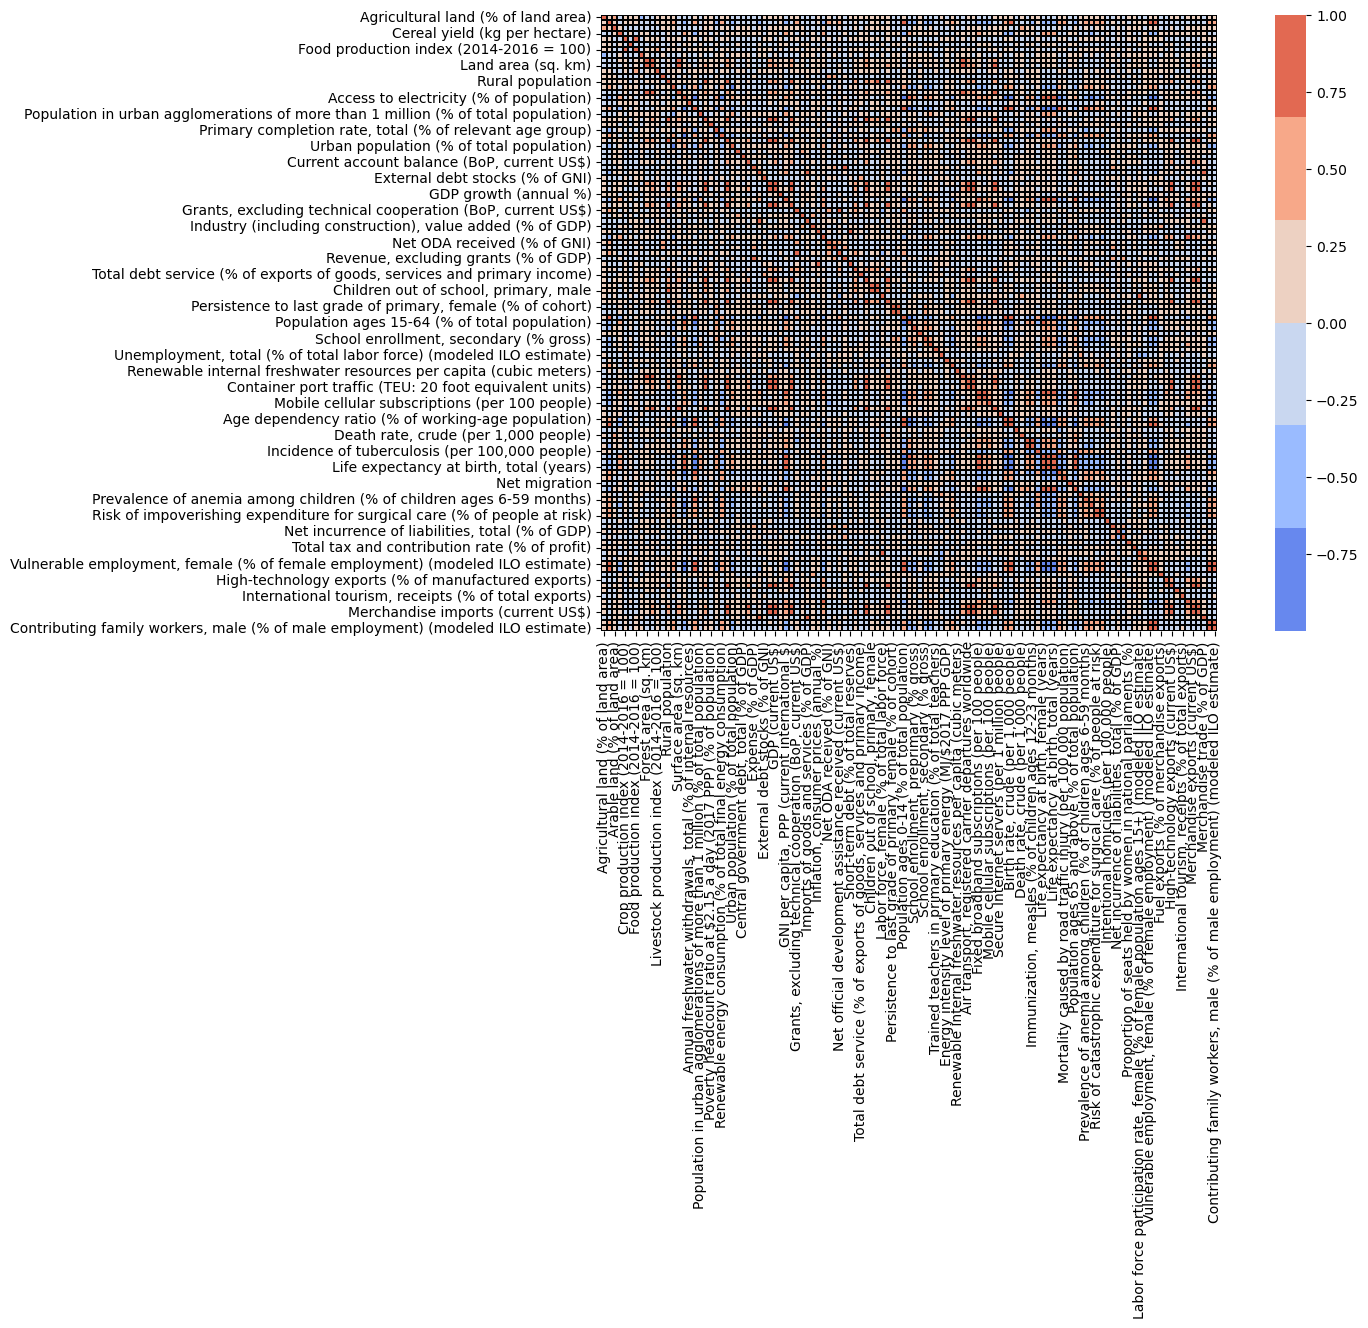

In [105]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(),
            square=True,
            linewidths=0.25,    
            linecolor=(0,0,0),
            cmap=sns.color_palette("coolwarm"),
            annot=False)
plt.show()

In [106]:
def remove_highly_correlated(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    dropped_vars = [column for column in upper.columns if any(upper[column] > threshold)]
    df_reduced = df.drop(columns=dropped_vars)
    
    return df_reduced, dropped_vars

In [107]:
df, drop_cols = remove_highly_correlated(df, threshold=0.8)

In [108]:
df.shape

(1016, 79)

# Modeling 

In [114]:
X = df[['GNI per capita, PPP (current international $)']]

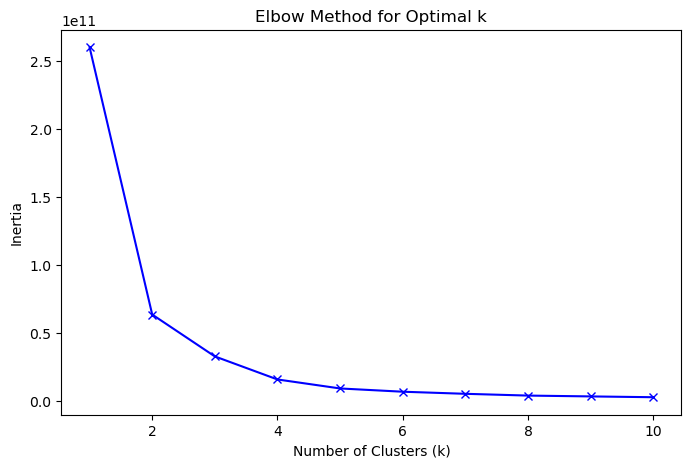

In [115]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K = range(1, 11) 

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [117]:
def dunn_index(X, labels):
    unique_clusters = np.unique(labels)

    # Compute cluster centroids
    centroids = np.array([
        X[labels == k].mean(axis=0) for k in unique_clusters
    ])
    
    from scipy.spatial.distance import cdist
    # Inter-cluster distance (minimum distance between clusters)
    inter_cluster_dist = np.min(
        cdist(centroids, centroids)[np.triu_indices(len(unique_clusters), k=1)]
    )

    # Intra-cluster distance (maximum cluster diameter)
    intra_cluster_dist = max(
        np.max(cdist(X[labels == k], X[labels == k]))
        for k in unique_clusters
    )
    return inter_cluster_dist / intra_cluster_dist

def evaluate_clustering(X, X_clusters):
    from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
    silhouette = silhouette_score(X, X_clusters)
    db = davies_bouldin_score(X, X_clusters)
    dunn = dunn_index(X, X_clusters)
    ch = calinski_harabasz_score(X, X_clusters)
    return silhouette, db, dunn, ch

In [118]:
#######################################################
# Construct a model
from sklearn.cluster import KMeans
selected_k = 2  # number of resulting clusters
selected_n_init = 10    # number of times the k-means algorithm is run with different centroid seeds
model = KMeans(n_clusters=selected_k, n_init=selected_n_init, random_state=23)   

X_clusters = model.fit_predict(X)
#######################################################

# Performance Evaluation
silhouette, db, dunn, ch = evaluate_clustering(X, X_clusters)
print('Silhouette Index: ', silhouette)
print('Davies-Bouldin Index: ', db)
print('Dunn Index: ', dunn)
print('CH Index: ', ch)

Silhouette Index:  0.7028636674713414
Davies-Bouldin Index:  0.46068516559574846
Dunn Index:  0.8727135557327769
CH Index:  3149.231893604819


In [119]:
def create_feature_boxplots(X, X_clusters):
    clustered_df = X.copy()
    clustered_df["Cluster"] = X_clusters
    cluster_means = clustered_df.groupby("Cluster").mean()

    # plot boxplots of feature values 
    for col in X.columns:
        clustered_df.boxplot(column=col, by="Cluster", figsize=(6, 4))
        plt.title(f"{col} by Cluster")
        plt.suptitle("")
        plt.show()

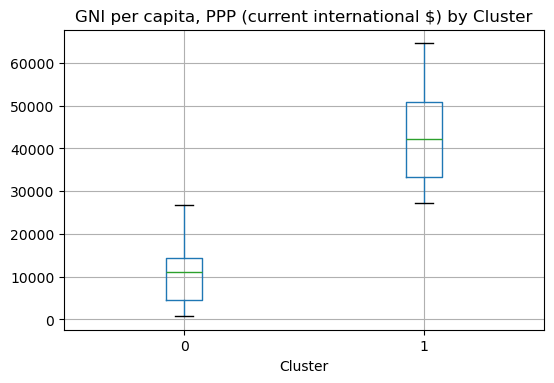

In [120]:
create_feature_boxplots(X, X_clusters)

In [131]:
df['Cluster'] = model.fit_predict(X)

In [132]:
summary_stats = df.groupby('Cluster')['GNI per capita, PPP (current international $)'].agg(['count', 'mean', 'std', 'min', 'max'])
print(summary_stats)

         count          mean           std      min      max
Cluster                                                     
0          773  10705.174644   6712.241533    780.0  26730.0
1          243  43309.753086  10852.221349  27240.0  64600.0
